In [1]:
import json
from pathlib import Path

# 改这里：选择任务/切分/语言
task = 'xnli'
split = 'train'
lang = 'zh'   # 非 en 才能测 R_align

root = Path('../data_qwen_sample')
files = sorted((root / task / split).glob(f"{lang}_Qwen3-8B_*.jsonl"))
en_files = sorted((root / task / split).glob("en_Qwen3-8B_*.jsonl"))
assert files, 'cannot find lang file'
assert en_files, 'cannot find en file for anchor'

path_lang = files[0]
path_en = en_files[0]
print('lang file:', path_lang)
print('en file:', path_en)

def read_jsonl(p):
    rows = []
    with p.open('r', encoding='utf-8') as f:
        for line in f:
            rows.append(json.loads(line))
    return rows

rows_lang = read_jsonl(path_lang)
rows_en = read_jsonl(path_en)

ex_lang = rows_lang[0]  # index=0
ex_en = rows_en[0]

cf_lang = ex_lang['counterfactual'][lang][9]  # 第10个 = gen_id 9
cf_en = ex_en['counterfactual']['en'][9]

print('orig index:', ex_lang['index'])
print('target_pred:', ex_lang['target_pred'][lang])
print('cf_lang:', cf_lang['text'])
print('cf_en(anchor):', cf_en['text'])


lang file: ../data_qwen_sample/xnli/train/zh_Qwen3-8B_260127_183029.jsonl
en file: ../data_qwen_sample/xnli/train/en_Qwen3-8B_260127_172050.jsonl
orig index: 0
target_pred: 1
cf_lang: 你 知道 当 他们 的 父母 来 了 , 很 难 让 他们 出来 , 很多 父母 有 事情 要 做 , 之类 的 东西 , 它 是 深夜 , 所以 ,
cf_en(anchor): you know when their parents come and it's hard to get them out and a lot of parents have places to go and and things like that and it's early in the morning so


In [2]:
# 1) 测 flip/aug + pred/conf/logit
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from reward_pred_aug import eval_one_example

local_model_dir = '/root/autodl-tmp/model/Qwen3-8B'

tokenizer = AutoTokenizer.from_pretrained(local_model_dir, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(local_model_dir, device_map='auto', torch_dtype=torch.bfloat16, trust_remote_code=True)

# 注意：use_chat_template 需要与你实际 tokenizer/model 对齐；若你之前跑数据时没开，这里也别开
use_chat_template = False

# 只评估这1条样本（会把 reward 写进 ex_lang 的 dict 里）
eval_one_example(task, lang, ex_lang, model, tokenizer, use_chat_template)

cf9 = ex_lang['counterfactual'][lang][9]
print('orig_pred_runtime:', ex_lang['orig_pred_runtime'][lang])
print('orig_confidence:', ex_lang['orig_confidence'][lang])
print('cf9 pred/conf:', cf9['pred'], cf9['confidence'])
print('cf9 reward_flip:', cf9.get('reward_flip'))
print('cf9 reward_aug/logit_gap_abs:', cf9.get('reward_aug'), cf9.get('logit_gap_abs'))


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


orig_pred_runtime: 0
orig_confidence: 0.87890625
cf9 pred/conf: 0 0.92578125
cf9 reward_flip: 0.0
cf9 reward_aug/logit_gap_abs: 4.25 4.25


In [3]:
# 2) 测 R_edit
from reward_edit_lev import reward_edit

if task == 'sib200':
    x = ex_lang['text'][lang]
    x_hat = cf_lang['text']
else:
    x = ex_lang['premise'][lang]
    x_hat = cf_lang['text']

r_edit = reward_edit(x_hat, x)
print('R_edit:', r_edit)


R_edit: 0.9315068493150684


In [4]:
# 3) 测 R_align（用 NLLB：从 非英语 counterfactual 翻回英语 anchor）
from reward_align_nllb import load_nllb, nllb_ce_loss_and_reward, LANG2NLLB

# 在 notebook cell 3) 里改成：
nllb_model, nllb_tok = load_nllb()

src_lang_code = LANG2NLLB[lang]
src_text = cf_lang['text']
tgt_text = cf_en['text']

losses, rewards = nllb_ce_loss_and_reward(nllb_model, nllb_tok, [src_text], [tgt_text], src_lang=src_lang_code, tgt_lang='eng_Latn')
print('CE_loss:', losses[0])
print('R_align:', rewards[0])


Loading weights:   0%|          | 0/1016 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


CE_loss: 1.89432373046875
R_align: 0.5278925961931302


In [6]:
# 4) 看四个 reward 放一起（这里只演示简单相乘；你后续可按论文/实验需要做加权）
cf9 = ex_lang['counterfactual'][lang][9]
r_flip = float(cf9.get('reward_flip', 0.0))
r_aug = float(cf9.get('reward_aug', 0.0))
r_align = float(rewards[0])
r_edit = float(r_edit)

print({'R_flip': r_flip, 'R_aug': r_aug, 'R_align': r_align, 'R_edit': r_edit})
print('demo_combined = R_flip + R_align + max(R_edit,0):', r_flip + r_align + max(r_edit, 0.0))


{'R_flip': 0.0, 'R_aug': 4.25, 'R_align': 0.5278925961931302, 'R_edit': 0.9315068493150684}
demo_combined = R_flip + R_align + max(R_edit,0): 1.4593994455081987


In [2]:
# 单个 cell：跑前10个样本(index 0-9)，把 4 个 reward 都算出来，并写到 ../data_qwen_reward/_debug/ 下
# 依赖：reward_pred_aug.py, reward_edit_lev.py, reward_align_nllb.py 都在当前 notebook 可 import 的路径里

import json
from pathlib import Path
import torch

from transformers import AutoTokenizer, AutoModelForCausalLM
from reward_pred_aug import eval_one_example
from reward_edit_lev import reward_edit
from reward_align_nllb import nllb_ce_loss_and_reward, LANG2NLLB

from transformers import AutoTokenizer as HF_AutoTokenizer, AutoModelForSeq2SeqLM

# ===== 0) 你可以改这里：选择一个要测试的文件 =====
task = "xnli"          # "sib200" or "xnli"
split = "train"
lang = "zh"            # 建议先用非 en，才能测试 align
in_root = Path("../data_qwen_sample").resolve()
out_root = Path("../data_qwen_reward_demo").resolve()

# 自动找到对应 jsonl（取第一个匹配）
lang_files = sorted((in_root / task / split).glob(f"{lang}_Qwen3-8B_*.jsonl"))
en_files   = sorted((in_root / task / split).glob("en_Qwen3-8B_*.jsonl"))
assert lang_files, f"cannot find {task}/{split}/{lang}_Qwen3-8B_*.jsonl under {in_root}"
assert en_files,   f"cannot find {task}/{split}/en_Qwen3-8B_*.jsonl under {in_root}"

path_lang = lang_files[0]
path_en = en_files[0]
print("[info] lang file:", path_lang)
print("[info] en file  :", path_en)

def read_jsonl(p: Path):
    rows = []
    with p.open("r", encoding="utf-8") as f:
        for line in f:
            rows.append(json.loads(line))
    return rows

rows_lang = read_jsonl(path_lang)[:10]   # 前10个样本
rows_en   = read_jsonl(path_en)[:10]
en_by_index = {ex["index"]: ex for ex in rows_en}

# ===== 1) 加载 Qwen classifier（用于 flip/aug/conf/pred）=====
qwen_dir = "/root/autodl-tmp/model/Qwen3-8B"
qwen_tok = AutoTokenizer.from_pretrained(qwen_dir, trust_remote_code=True)
qwen_mdl = AutoModelForCausalLM.from_pretrained(
    qwen_dir, device_map="auto", torch_dtype=torch.bfloat16, trust_remote_code=True
)

use_chat_template = False  # 跟你之前生成 orig_pred 时一致

# ===== 2) 加载 NLLB（用于 align；这里用 HF hub，避免你本地模型混乱）=====
# 文档示例：AutoTokenizer/AutoModelForSeq2SeqLM.from_pretrained("facebook/nllb-200-distilled-1.3B") [web:21]
nllb_name = "/root/autodl-tmp/model/nllb-200-distilled-1.3B"
nllb_tok = HF_AutoTokenizer.from_pretrained(nllb_name)
nllb_mdl = AutoModelForSeq2SeqLM.from_pretrained(nllb_name, device_map="auto", torch_dtype=torch.bfloat16)

# ===== 3) 处理前10条：写入 reward =====
processed = []
for ex in rows_lang:
    idx = ex["index"]

    # 3.1 pred/conf/flip/aug（会把 orig 和每个 cf 的 pred/conf/flip/aug 写回 ex）
    eval_one_example(task, lang, ex, qwen_mdl, qwen_tok, use_chat_template=use_chat_template)

    # 3.2 edit reward
    x_orig = ex["text"][lang] if task == "sib200" else ex["premise"][lang]
    for cf in ex.get("counterfactual", {}).get(lang, []):
        cf["reward_edit"] = float(reward_edit(cf["text"], x_orig))

    # 3.3 align reward（非英语才做；用“同 index 的英文文件”作为 anchor）
    if lang != "en":
        ex_en = en_by_index.get(idx)
        if ex_en is not None:
            cfs_lang = ex.get("counterfactual", {}).get(lang, [])
            cfs_en   = ex_en.get("counterfactual", {}).get("en", [])
            n = min(len(cfs_lang), len(cfs_en))
            if n > 0:
                src_texts = [cfs_lang[i]["text"] for i in range(n)]
                tgt_texts = [cfs_en[i]["text"] for i in range(n)]
                src_lang_code = LANG2NLLB[lang]  # e.g. zh -> zho_Hans
                losses, rewards = nllb_ce_loss_and_reward(
                    nllb_mdl, nllb_tok, src_texts, tgt_texts, src_lang=src_lang_code, tgt_lang="eng_Latn"
                )
                for i in range(n):
                    cfs_lang[i]["reward_align"] = float(rewards[i])
                    cfs_lang[i]["align_ce_loss"] = float(losses[i])

    processed.append(ex)

# ===== 4) 写一个 debug 输出文件，并展示“长什么样” =====
out_path = (out_root / "_debug" / task / split / f"{lang}_first10_reward.jsonl")
out_path.parent.mkdir(parents=True, exist_ok=True)
with out_path.open("w", encoding="utf-8") as f:
    for ex in processed:
        f.write(json.dumps(ex, ensure_ascii=False) + "\n")

print("[ok] wrote:", out_path)
print("\n[peek] first example keys:", list(processed[0].keys())[:25])
print("[peek] first example first cf keys:", list(processed[0]["counterfactual"][lang][0].keys()))
print("\n[peek] first example first cf snippet:")
print(json.dumps(processed[0]["counterfactual"][lang][0], ensure_ascii=False, indent=2)[:1200])


[info] lang file: /root/autodl-tmp/Multilingual CFE RL/data_qwen_sample/xnli/train/zh_Qwen3-8B_260127_183029.jsonl
[info] en file  : /root/autodl-tmp/Multilingual CFE RL/data_qwen_sample/xnli/train/en_Qwen3-8B_260127_172050.jsonl


Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu.


Loading weights:   0%|          | 0/1016 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


[ok] wrote: /root/autodl-tmp/Multilingual CFE RL/data_qwen_reward_demo/_debug/xnli/train/zh_first10_reward.jsonl

[peek] first example keys: ['index', 'premise', 'hypothesis', 'label', 'orig_pred', 'orig_pred_text', 'orig_pred_logprob', 'orig_pred_token_logprobs', 'target_pred', 'counterfactual', 'orig_pred_runtime', 'orig_confidence', 'orig_label_logits', 'orig_label_probs', 'orig_logit_gap_abs_to_target']
[peek] first example first cf keys: ['gen_id', 'text', 'pred', 'pred_text', 'confidence', 'label_logits', 'label_probs', 'reward_flip', 'reward_aug', 'logit_gap_abs', 'reward_edit', 'reward_align', 'align_ce_loss']

[peek] first example first cf snippet:
{
  "gen_id": 0,
  "text": "你 知道 当 他们 的 父母 来 了 , 很 难 让 他们 出来 , 很多 父母 有 事 去 , 之类 的 东西 , 它 是 深夜 , 所以",
  "pred": 0,
  "pred_text": "0",
  "confidence": 0.94921875,
  "label_logits": {
    "0": 26.875,
    "1": 22.5,
    "2": 23.625
  },
  "label_probs": {
    "0": 0.94921875,
    "1": 0.011962890625,
    "2": 0.036865234375
  },
  "re

In [1]:
import json
from pathlib import Path
from collections import defaultdict
import numpy as np

root = Path("../data_qwen_reward").resolve()

# 1) 找到所有 jsonl
jsonl_files = sorted(root.rglob("*.jsonl"))
print(f"[info] found {len(jsonl_files)} jsonl files under {root}")

# 2) 你这份数据里 cf 的字段（按你样例）
METRICS = [
    "reward_flip",
    "reward_aug_flip",
    "reward_aug_noflip",
    "logit_gap_abs_flip",
    "logit_gap_abs_noflip",
    "reward_edit",
    "reward_align",
    "align_ce_loss",
]

def safe_float(x):
    """return float or None"""
    try:
        v = float(x)
        if np.isfinite(v):
            return v
        return None
    except Exception:
        return None

# 3) 容器：按 lang 统计，另外给全局 all
vals = defaultdict(lambda: {k: [] for k in METRICS})
missing = defaultdict(lambda: {k: 0 for k in METRICS})

num_examples = 0
num_cfs = 0
num_cfs_by_lang = defaultdict(int)

for fp in jsonl_files:
    # 约定：文件名形如 ar_Qwen3-8B_*.jsonl -> lang="ar"
    lang = fp.name.split("_", 1)[0]

    with fp.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            try:
                ex = json.loads(line)
            except Exception:
                continue

            num_examples += 1

            cfs_by_lang = ex.get("counterfactual", {})
            cfs = cfs_by_lang.get(lang, [])
            if not isinstance(cfs, list):
                continue

            for cf in cfs:
                if not isinstance(cf, dict):
                    continue
                num_cfs += 1
                num_cfs_by_lang[lang] += 1

                # push metrics (per-lang + global all)
                for k in METRICS:
                    v = safe_float(cf.get(k, None))
                    if v is None:
                        missing[lang][k] += 1
                        missing["all"][k] += 1
                    else:
                        vals[lang][k].append(v)
                        vals["all"][k].append(v)

print(f"[info] parsed examples={num_examples}, counterfactuals={num_cfs}")
print("[info] counterfactuals by lang:", dict(num_cfs_by_lang))

def summarize(arr):
    """arr: list[float] -> dict stats"""
    if len(arr) == 0:
        return None
    x = np.asarray(arr, dtype=np.float64)
    return {
        "n": int(x.size),
        "mean": float(np.mean(x)),
        "std": float(np.std(x)),
        "min": float(np.min(x)),
        "p05": float(np.quantile(x, 0.05)),
        "p50": float(np.quantile(x, 0.50)),
        "p95": float(np.quantile(x, 0.95)),
        "max": float(np.max(x)),
    }

def summarize_flip(arr):
    """reward_flip: usually 0/1"""
    if len(arr) == 0:
        return None
    x = np.asarray(arr, dtype=np.float64)
    c0 = int(np.sum(x == 0))
    c1 = int(np.sum(x == 1))
    return {
        "n": int(x.size),
        "count_0": c0,
        "count_1": c1,
        "flip_rate": float(c1 / max(1, x.size)),
    }

def print_report(lang="all"):
    print("\n" + "=" * 80)
    print(f"[report] lang={lang}")
    print("[missing]", missing[lang])

    # reward_flip 单独统计
    flip_stats = summarize_flip(vals[lang]["reward_flip"])
    print("[reward_flip]", flip_stats)

    # 其他指标分布统计
    for k in METRICS:
        if k == "reward_flip":
            continue
        stats = summarize(vals[lang][k])
        print(f"[{k}]", stats)

# 打印全局
print_report("all")

# 如需也打印每种语言，把下面取消注释
# for lang in sorted(num_cfs_by_lang.keys()):
#     print_report(lang)


[info] found 1 jsonl files under /root/autodl-tmp/Multilingual CFE RL/data_qwen_reward
[info] parsed examples=36, counterfactuals=360
[info] counterfactuals by lang: {'ar': 360}

[report] lang=all
[missing] {'reward_flip': 0, 'reward_aug_flip': 0, 'reward_aug_noflip': 0, 'logit_gap_abs_flip': 0, 'logit_gap_abs_noflip': 0, 'reward_edit': 0, 'reward_align': 0, 'align_ce_loss': 0}
[reward_flip] {'n': 360, 'count_0': 166, 'count_1': 194, 'flip_rate': 0.5388888888888889}
[reward_aug_flip] {'n': 360, 'mean': 0.5258051043705338, 'std': 0.3439282853855501, 'min': 0.0031726828424851893, 'p05': 0.0066928509242848554, 'p50': 0.5926665999540697, 'p95': 0.9840936082881853, 'max': 0.9940889311437562}
[reward_aug_noflip] {'n': 360, 'mean': 0.40552692809793517, 'std': 0.39080793528965024, 'min': 0.0024726231566347743, 'p05': 0.0024726231566347743, 'p50': 0.2570132172511834, 'p95': 0.9579122720843811, 'max': 0.9890130573694068}
[logit_gap_abs_flip] {'n': 360, 'mean': 6.0375, 'std': 2.5598699239957052, 

[info] found 6 jsonl files under /root/autodl-tmp/Multilingual CFE RL/data_qwen_reward_demo5
[info] parsed lines=60, counterfactuals=600
[info] counts: {'reward_flip': 600, 'reward_aug_flip': 600, 'reward_aug_noflip': 600, 'logit_gap_abs_flip': 600, 'logit_gap_abs_noflip': 600, 'reward_edit': 600, 'reward_align': 400, 'align_ce_loss': 400}
[info] missing: {'reward_flip': 0, 'reward_aug_flip': 0, 'reward_aug_noflip': 0, 'logit_gap_abs_flip': 0, 'logit_gap_abs_noflip': 0, 'reward_edit': 0, 'reward_align': 200, 'align_ce_loss': 200}
[info] counterfactual counts by lang: {'de': 200, 'en': 200, 'zh': 200}


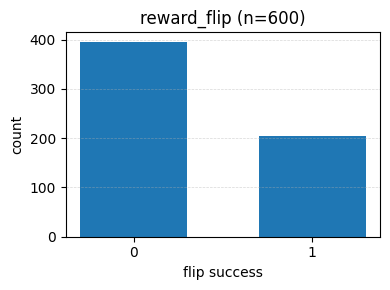

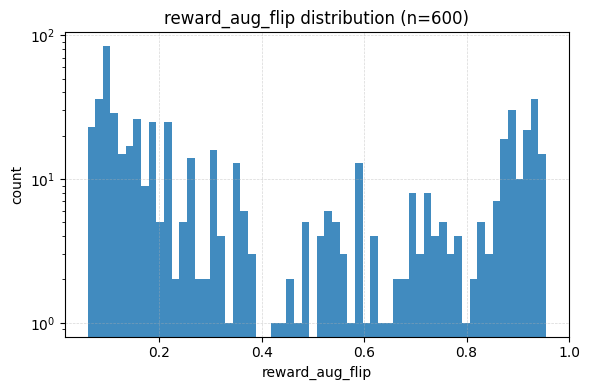

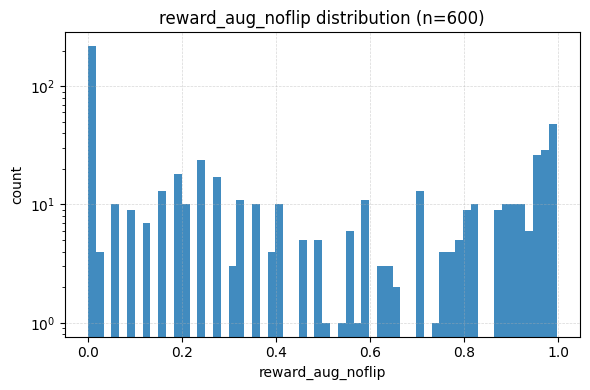

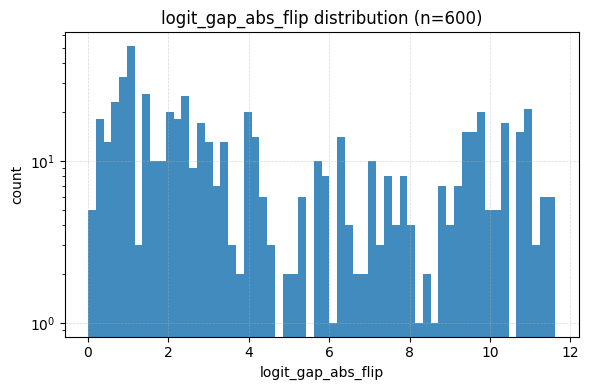

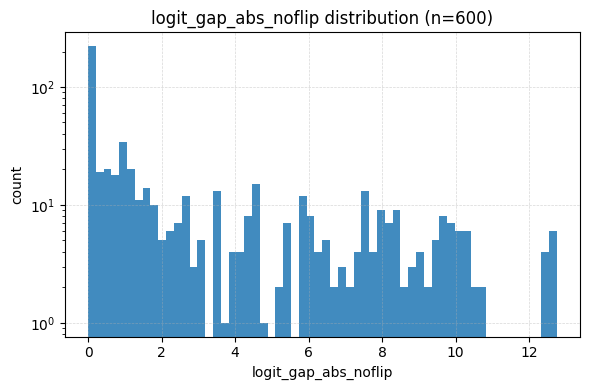

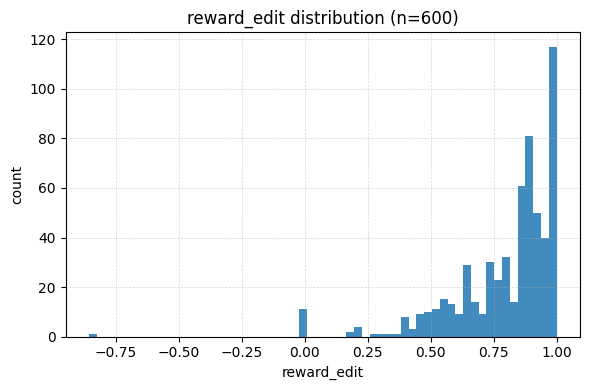

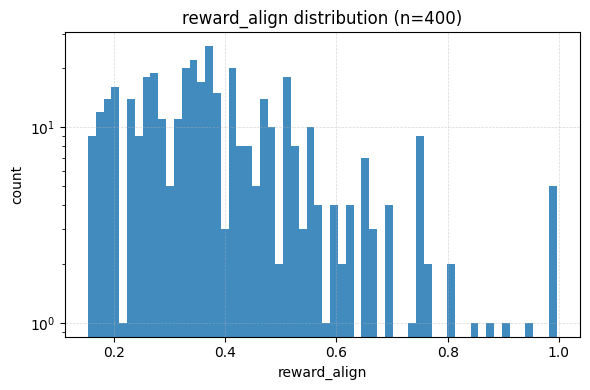

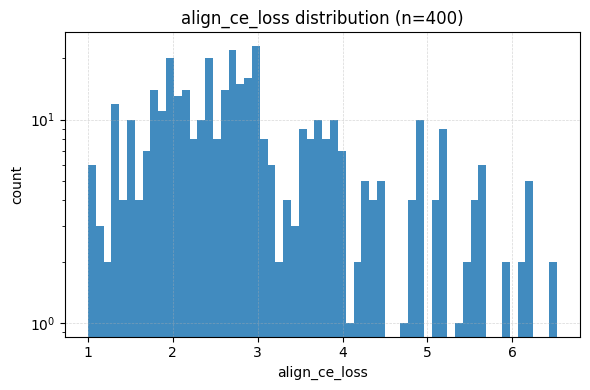


[info] quick stats:
reward_aug_flip {'n': 600, 'mean': 0.41432919399650714, 'p50': 0.24508501313237172, 'p90': 0.9196425311777929, 'p99': 0.9497258650257714, 'min': 0.060086650174007626, 'max': 0.9553191297273498}
reward_aug_noflip {'n': 600, 'mean': 0.33232596739068704, 'p50': 0.2449186624037092, 'p90': 0.9700858268137, 'p99': 0.9961488611460875, 'min': -0.9106382594546996, 'max': 0.9965985551771297}
logit_gap_abs_flip {'n': 600, 'mean': 4.659583333333333, 'p50': 3.25, 'p90': 10.375, 'p99': 11.377499999999998, 'min': 0.0, 'max': 11.625}
logit_gap_abs_noflip {'n': 600, 'mean': 2.4964583333333334, 'p50': 1.0, 'p90': 8.375, 'p99': 12.501249999999999, 'min': -6.125, 'max': 12.75}
reward_edit {'n': 600, 'mean': 0.7982119263046307, 'p50': 0.867888307155323, 'p90': 1.0, 'p99': 1.0, 'min': -0.8571428571428572, 'max': 1.0}
reward_align {'n': 400, 'mean': 0.39466420140173225, 'p50': 0.36480528375038834, 'p90': 0.6192292887405803, 'p99': 0.9957524494302807, 'min': 0.15338523710807628, 'max': 0.

In [13]:
import json
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt


# =============== 配置区 ===============
root = Path("../data_qwen_reward_demo5").resolve()

# 你关心的数值字段（按你示例里的 key）
NUM_KEYS = [
    "reward_flip",
    "reward_aug_flip",
    "reward_aug_noflip",
    "logit_gap_abs_flip",
    "logit_gap_abs_noflip",
    "reward_edit",
    "reward_align",
    "align_ce_loss",
]

# 一些直方图建议的裁剪范围（可按你数据分布再调）
CLIPS = {
    "reward_aug_flip": (0, 1.2),
    "reward_aug_noflip": (0, 1.2),
    "logit_gap_abs_flip": (0, 30),
    "logit_gap_abs_noflip": (0, 30),
    "reward_edit": (-1, 1),
    "reward_align": (0, 5),
    "align_ce_loss": (0, 15),
}

LOGY = {
    "reward_aug_flip": True,
    "reward_aug_noflip": True,
    "logit_gap_abs_flip": True,
    "logit_gap_abs_noflip": True,
    "reward_align": True,
    "align_ce_loss": True,
}
# =====================================


def safe_float(x):
    """转 float 并过滤 nan/inf；失败返回 None。"""
    if x is None:
        return None
    try:
        v = float(x)
    except Exception:
        return None
    if not np.isfinite(v):
        return None
    return v


def iter_counterfactuals(ex):
    """
    从一条样本 ex 中迭代所有 counterfactual（跨语言）。
    兼容：counterfactual 是 dict(lang -> list[cf]) 或直接是 list[cf]（少见但防御）。
    """
    c = ex.get("counterfactual", None)
    if c is None:
        return

    if isinstance(c, dict):
        for lang, lst in c.items():
            if isinstance(lst, list):
                for cf in lst:
                    if isinstance(cf, dict):
                        yield lang, cf
    elif isinstance(c, list):
        for cf in c:
            if isinstance(cf, dict):
                yield None, cf


def plot_hist(name, data, bins=60, clip=None, logy=False):
    if not data:
        print(f"[skip] {name}: no data")
        return

    x = np.array(data, dtype=np.float64)
    if clip is not None:
        lo, hi = clip
        x = np.clip(x, lo, hi)

    plt.figure(figsize=(6, 4))
    plt.hist(x, bins=bins, alpha=0.85)
    plt.title(f"{name} distribution (n={len(x)})")
    plt.xlabel(name)
    plt.ylabel("count")
    if logy:
        plt.yscale("log")  # 直方图长尾时常用 [web:1]
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
    plt.tight_layout()
    plt.show()


def plot_flip_bar(data):
    if not data:
        print("[skip] reward_flip: no data")
        return
    x = np.array(data, dtype=np.float64)

    # 兼容 reward_flip 是 0/1 或 bool 或其它数值：统一按 “==1” 统计成功
    c0 = int(np.sum(x == 0))
    c1 = int(np.sum(x == 1))

    plt.figure(figsize=(4, 3))
    plt.bar([0, 1], [c0, c1], width=0.6)
    plt.xticks([0, 1], ["0", "1"])
    plt.title(f"reward_flip (n={len(x)})")
    plt.xlabel("flip success")
    plt.ylabel("count")
    plt.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
    plt.tight_layout()
    plt.show()


# =============== 主流程：读取与统计 ===============
jsonl_files = sorted(root.rglob("*.jsonl"))
print(f"[info] found {len(jsonl_files)} jsonl files under {root}")

vals = {k: [] for k in NUM_KEYS}
missing = {k: 0 for k in NUM_KEYS}

# 额外做一些按语言的统计（可选）
vals_by_lang = defaultdict(lambda: {k: [] for k in NUM_KEYS})
missing_by_lang = defaultdict(lambda: {k: 0 for k in NUM_KEYS})

num_lines = 0
num_cfs = 0

for fp in jsonl_files:
    with fp.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            num_lines += 1
            try:
                ex = json.loads(line)
            except Exception:
                # 行级别坏数据直接跳过
                continue

            for lang, cf in iter_counterfactuals(ex):
                num_cfs += 1

                for k in NUM_KEYS:
                    v = safe_float(cf.get(k))
                    if v is None:
                        missing[k] += 1
                        missing_by_lang[lang][k] += 1
                    else:
                        vals[k].append(v)
                        vals_by_lang[lang][k].append(v)

print(f"[info] parsed lines={num_lines}, counterfactuals={num_cfs}")
print("[info] counts:", {k: len(v) for k, v in vals.items()})
print("[info] missing:", missing)

# 也可以看每种语言的样本量（如果你确实是多语言混在一起）
langs_sorted = sorted(vals_by_lang.keys(), key=lambda x: str(x))
print("[info] counterfactual counts by lang:",
      {str(lang): len(vals_by_lang[lang]['reward_flip']) for lang in langs_sorted})


# =============== 画图 ===============
plot_flip_bar(vals["reward_flip"])

for k in NUM_KEYS:
    if k == "reward_flip":
        continue
    plot_hist(
        k,
        vals[k],
        bins=60,
        clip=CLIPS.get(k),
        logy=LOGY.get(k, False),
    )


def describe(name, data):
    if not data:
        return None
    x = np.array(data, dtype=np.float64)
    return {
        "n": int(len(x)),
        "mean": float(np.mean(x)),
        "p50": float(np.percentile(x, 50)),
        "p90": float(np.percentile(x, 90)),
        "p99": float(np.percentile(x, 99)),
        "min": float(np.min(x)),
        "max": float(np.max(x)),
    }

print("\n[info] quick stats:")
for k in NUM_KEYS:
    if k == "reward_flip":
        continue
    d = describe(k, vals[k])
    print(k, d)
